**Binisha Shakya**  
**2407792**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Exercise - 1:
Complete all the Task.
1. Read and display the image.

• Read the image using the Pillow library and display it.

• You can also use matplotlib to display the image.

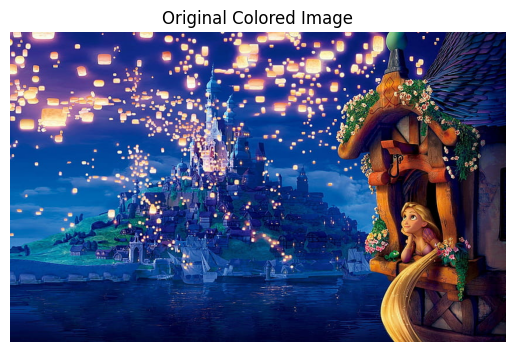

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
image_colored = Image.open("/content/drive/MyDrive/AI & ML/Week1/rxx.jpg")
plt.imshow(image_colored)
plt.title("Original Colored Image")
plt.axis("off")
plt.show()

FOR COLORED IMAGE


In [ ]:
print ( " Image Format : " , image_colored . format )
print ( " Image Size : " , image_colored . size )
print ( " Image Mode : " , image_colored . mode )

 Image Format :  JPEG
 Image Size :  (850, 531)
 Image Mode :  RGB


Converting into numpy

In [ ]:
# Get the size (width, height) and channels (RGB)
width, height = image_colored.size
channels= len (image_colored.getbands())
print(f"Image shape (RGB) :({height} , {width} , {channels})")
image_size_colored = width*height*3
print(f"Image size (RGB) : {image_size_colored}")

Image shape (RGB) :(531 , 850 , 3)
Image size (RGB) : 1354050


In [ ]:
import numpy as np
image_colored_np = np.array(image_colored)
image_colored_np.shape
print("Shape of the image array: ",image_colored_np.shape)

Shape of the image array:  (531, 850, 3)


if working in colored channel [ width,height,colored]
R- index 0.
G- index 1.
B- index 2

2. Display only the top left corner of 100x100 pixels.

• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.

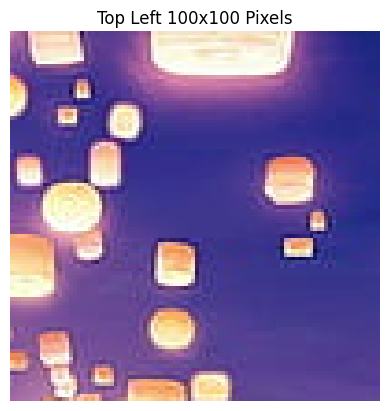

In [7]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Re-defining image_colored and image_colored_np to ensure they are available
image_colored = Image.open("/content/drive/MyDrive/AI & ML/Week1/rxx.jpg")
image_colored_np = np.array(image_colored)

image_array = image_colored_np

top_left = image_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left 100x100 Pixels")
plt.axis("off")
plt.show()

3. Show the three color channels (R, G, B).

• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}

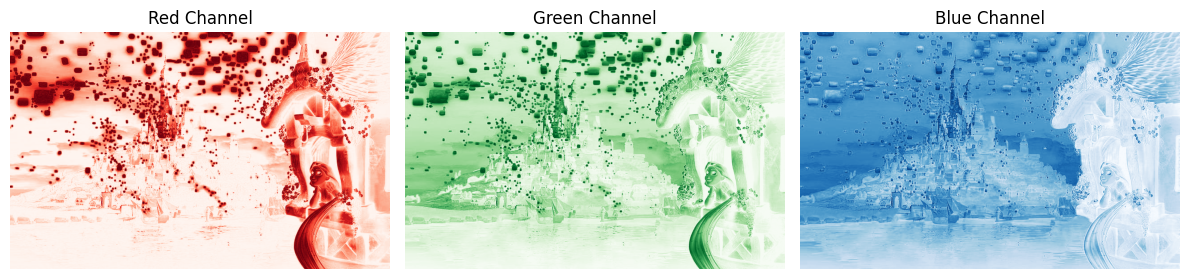

In [9]:
red_channel = image_array[:, :, 0]
green_channel = image_array[:, :, 1]
blue_channel = image_array[:, :, 2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(red_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(green_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blue_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:

• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

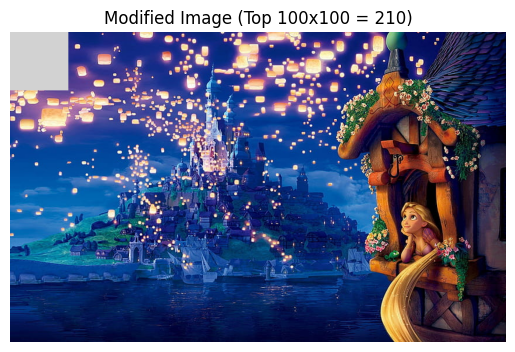

In [10]:
modified_image = image_array.copy()

modified_image[0:100, 0:100] = 210

plt.imshow(modified_image)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

Exercise - 2:

Complete all the Task.
1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.

Greyscale image

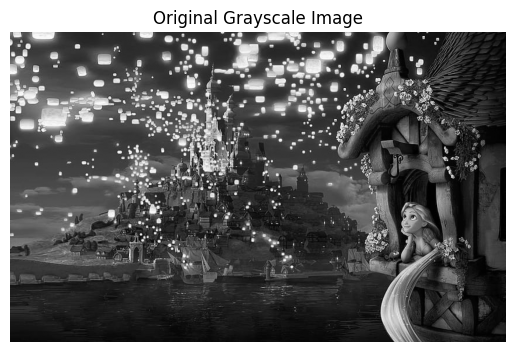

In [15]:
image_grayed = Image.open("/content/drive/MyDrive/AI & ML/Week1/rxx.jpg").convert("L")
image_array_grayed = np.array(image_grayed)
plt.imshow(image_array_grayed, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

PCA = principle component analysis
PCA is used feature extraction algorithm


2. Extract and display the middle section of the image (150 pixels).

• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib.

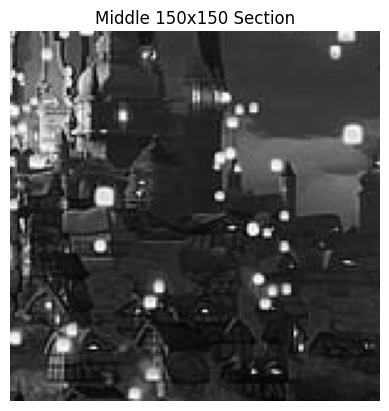

In [16]:
height, width = image_array_grayed.shape

center_h = height // 2
center_w = width // 2

middle_section = image_array_grayed[
    center_h-75:center_h+75,
    center_w-75:center_w+75
]

plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).

• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).

• Display the resulting binary image.

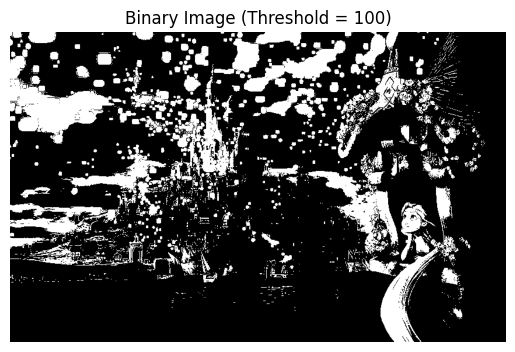

In [17]:
binary_image = np.where(image_array_grayed < 100, 0, 255)

plt.imshow(binary_image, cmap="gray")
plt.title("Binary Image (Threshold = 100)")
plt.axis("off")
plt.show()

4. Rotate the image 90 degrees clockwise and display the result.

• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.

• Display the rotated image using matplotlib.

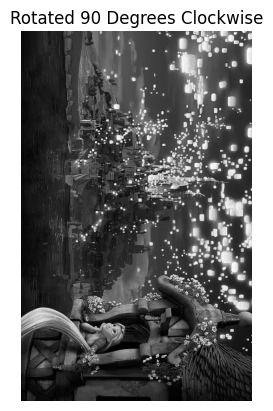

In [18]:
rotated_image = image_grayed.rotate(-90, expand=True)

plt.imshow(rotated_image, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

5. Convert the grayscale image to an RGB image.

• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).

• Display the converted RGB image using matplotlib.

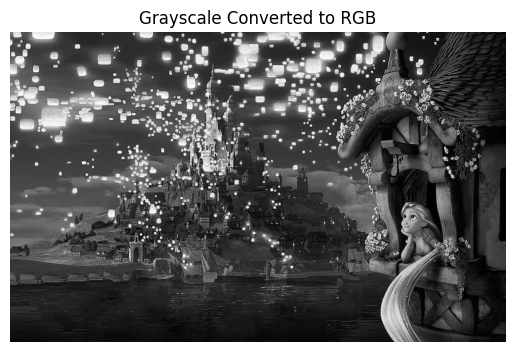

In [19]:
rgb_image = image_grayed.convert("RGB")

plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

In [21]:
print("RGB Image Mode:", rgb_image.mode)
print("Number of bands (channels) in RGB image:", len(rgb_image.getbands()))

RGB Image Mode: RGB
Number of bands (channels) in RGB image: 3


3. Image Compression and Decompression using PCA.

1. Load and Prepare Data:

• Fetch an image of you choice.{If colour convert to grayscale}


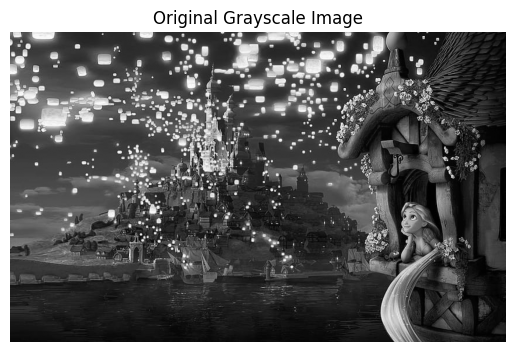

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image_colored = Image.open("/content/drive/MyDrive/AI & ML/Week1/rxx.jpg")

# Convert to grayscale as specified in the task for colored images
image_grayed = image_colored.convert("L")
image_array = np.array(image_grayed)

height, width = image_array.shape

data = image_array.reshape(height, width)

plt.imshow(image_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

• Center the dataset - Standaridze the Data.

In [26]:
mean = np.mean(data, axis=0)
centered_data = data - mean

• Calculate the covaraince matrix of the Standaridze data.

In [27]:
cov_matrix = np.cov(centered_data, rowvar=False)

print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (850, 850)


2. Eigen Decomposition and Identifying Principal Components:

• Compute Eigen Values and Eigen Vectors.


In [28]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print("Eigenvalues Shape:", eigenvalues.shape)
print("Eigenvectors Shape:", eigenvectors.shape)

Eigenvalues Shape: (850,)
Eigenvectors Shape: (850, 850)


• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.

In [29]:
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]


k = 50
top_k_eigenvectors = eigenvectors[:, :k]

print("Top k Eigenvectors Shape:", top_k_eigenvectors.shape)

Top k Eigenvectors Shape: (850, 50)


Identify the Principal Components with the help of cumulative Sum plot.

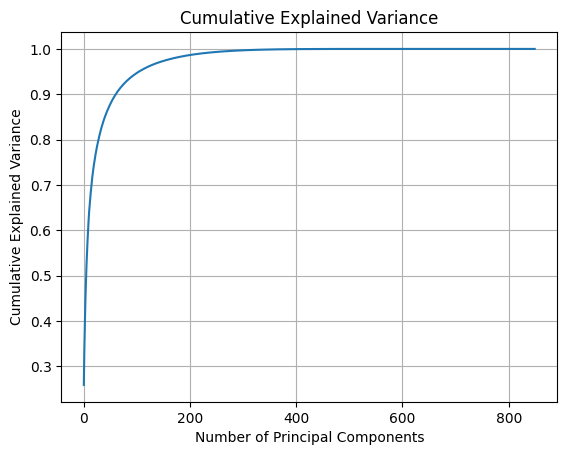

In [30]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

cumulative_variance = np.cumsum(explained_variance_ratio)

plt.plot(cumulative_variance)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

In [31]:
compressed_data = np.dot(centered_data, top_k_eigenvectors)

print("Compressed Data Shape:", compressed_data.shape)

Compressed Data Shape: (531, 50)


In [32]:
reconstructed_image = np.dot(compressed_data, top_k_eigenvectors.T) + mean

print("Reconstructed Image Shape:", reconstructed_image.shape)

Reconstructed Image Shape: (531, 850)


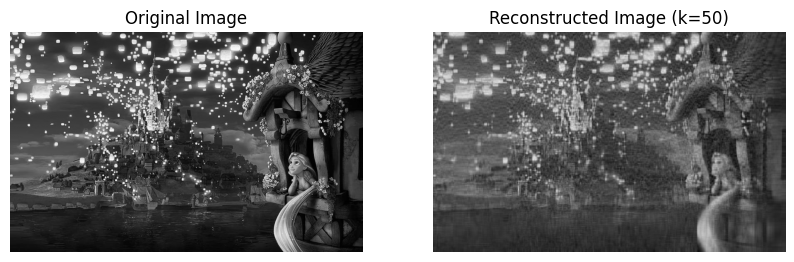

In [33]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reconstructed_image, cmap="gray")
plt.title(f"Reconstructed Image (k={k})")
plt.axis("off")

plt.show()

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

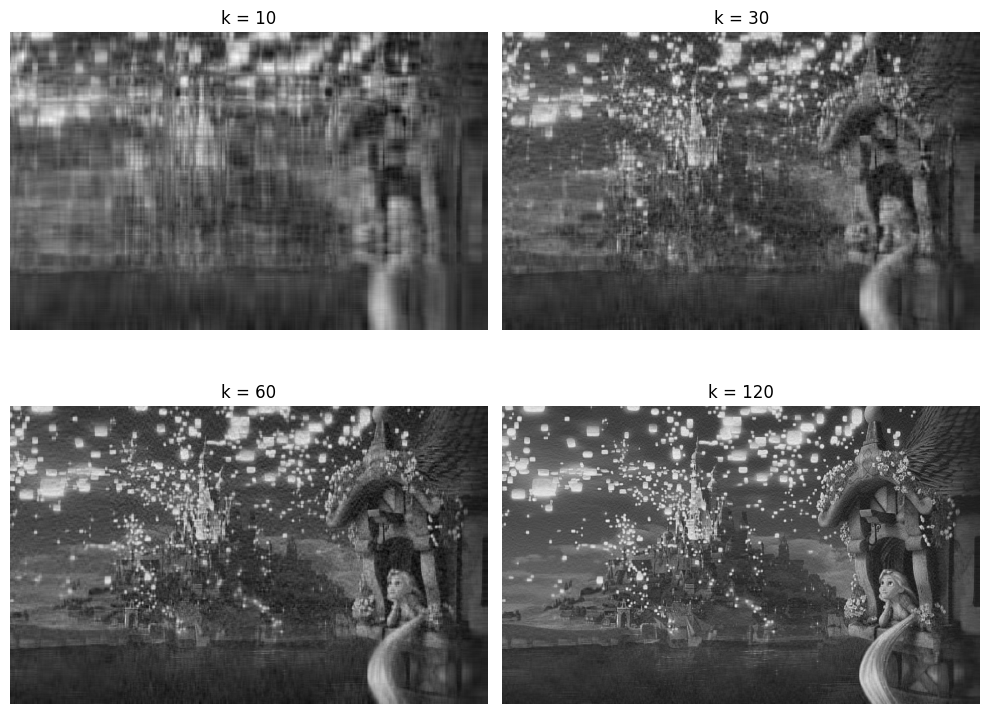

In [34]:
k_values = [10, 30, 60, 120]

plt.figure(figsize=(10,8))

for i, k in enumerate(k_values):
    components = eigenvectors[:, :k]
    compressed = np.dot(centered_data, components)
    reconstructed = np.dot(compressed, components.T) + mean

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

• Display the Results and Evaluate.

In [35]:
# Display the Results and Evaluate.
# Calculate and display quantitative evaluation metrics (e.g., Mean Squared Error)
# for different numbers of principal components (k).

k_values = [10, 30, 60, 120]

print("--- Evaluation of Image Compression ---")
for k in k_values:
    # Reconstruct the image with the current k value
    # 'centered_data', 'eigenvectors', 'mean' are available from previous cells.
    components = eigenvectors[:, :k]
    compressed = np.dot(centered_data, components)
    reconstructed = np.dot(compressed, components.T) + mean

    # Calculate Mean Squared Error (MSE)
    # Ensure both arrays are of compatible types and shapes for subtraction
    # The reconstructed image might have float values, so cast original to float for accurate comparison
    mse = np.mean((image_array.astype(float) - reconstructed)**2)
    print(f"k = {k}: Mean Squared Error (MSE) = {mse:.2f}")

print("\n--- Qualitative Assessment ---")
print("As observed from the previously displayed images:")
print("- For small k (e.g., 10, 30), the image is highly compressed, leading to significant loss of detail and a blurry appearance.")
print("- As k increases (e.g., 60, 120), more principal components are retained, and the reconstructed image becomes progressively clearer and more similar to the original.")
print("- A balance needs to be struck between compression ratio (lower k) and image quality (higher k).")

--- Evaluation of Image Compression ---
k = 10: Mean Squared Error (MSE) = 1059.49
k = 30: Mean Squared Error (MSE) = 540.02
k = 60: Mean Squared Error (MSE) = 285.95
k = 120: Mean Squared Error (MSE) = 112.88

--- Qualitative Assessment ---
As observed from the previously displayed images:
- For small k (e.g., 10, 30), the image is highly compressed, leading to significant loss of detail and a blurry appearance.
- As k increases (e.g., 60, 120), more principal components are retained, and the reconstructed image becomes progressively clearer and more similar to the original.
- A balance needs to be struck between compression ratio (lower k) and image quality (higher k).
